<a href="https://colab.research.google.com/github/24cseaiml023satwikbarik-bit/AML-LAB/blob/main/AMLexp4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import numpy as np
import matplotlib.pyplot as plt
x=np.array([1,2,3],dtype=float)
y=np.array([2,3,4],dtype=float)
n=len(x)
w=0.0
b=0.0
alpha=0.05
iterations=2
print("Initial weight(w):",w)
print("Initial bias(b):",b)

Initial weight(w): 0.0
Initial bias(b): 0.0


In [4]:
def predict(x,w,b):
  return w*x+b

In [5]:
y_pred=predict(x,w,b)
print("Predicted value:",y_pred)

Predicted value: [0. 0. 0.]


In [6]:
def compute_cost(y,y_pred):
  return np.sum((y-y_pred)**2)/(n)

In [17]:
cost=compute_cost(y,y_pred)
print("Cost:",cost)

Cost: 0.10455846867855513


In [9]:
def del_JW(x,y,y_pred):
  return -2/n*np.sum((y-y_pred)*x),-2/n*np.sum((y-y_pred))

In [13]:
dw,db=del_JW(x,y,y_pred)
print("dw:",dw)
print("db:",db)

dw: -13.333333333333332
db: -6.0


In [14]:
def update(w,b,dw,db,alpha):
  return w-alpha*dw,b-alpha*db
w,b=update(w,b,dw,db,alpha)
print("Updated weight(w):",w)
print("Updated bias(b):",b)

Updated weight(w): 0.6666666666666666
Updated bias(b): 0.30000000000000004


In [16]:
y_pred=predict(x,w,b)
print("Predicted:",y_pred)
cost=compute_cost(y,y_pred)
print("Cost:",cost)
#iteration 2 starts

Predicted: [1.59307407 2.68559259 3.77811111]
Cost: 0.10455846867855513


In [27]:
print("\nStarting Gradient Descent Loop:")

# Reset w and b to initial values (0.0) for the start of gradient descent
# This ensures the loop always starts from the same origin, overriding previous cell's updates.
w = 0.0
b = 0.0

# Calculate and store the initial cost (Iteration 0)
y_pred_initial = predict(x, w, b)
initial_cost = compute_cost(y, y_pred_initial)
cost_history = [initial_cost] # Store cost at iteration 0

print(f"Iteration 0: Cost={initial_cost:.6f}, w={w:.6f}, b={b:.6f}") # Print initial state

for i in range(iterations):
    # Calculate gradients with current w, b using the current w and b
    y_pred_current = predict(x, w, b)
    dw, db = del_JW(x, y, y_pred_current)

    # Update w and b based on the calculated gradients
    w, b = update(w, b, dw, db, alpha)

    # Calculate cost AFTER the update for the current iteration (i+1)
    y_pred_after_update = predict(x, w, b)
    cost_after_update = compute_cost(y, y_pred_after_update)
    cost_history.append(cost_after_update) # Store cost for iteration i+1

    print(f"Iteration {i+1}: Cost={cost_after_update:.6f}, w={w:.6f}, b={b:.6f}")

print("\nFinal values after gradient descent:")
print(f"Final Weight(w): {w:.6f}")
print(f"Final Bias(b): {b:.6f}")


Starting Gradient Descent Loop:
Iteration 0: Cost=9.666667, w=0.000000, b=0.000000
Iteration 1: Cost=1.941852, w=0.666667, b=0.300000
Iteration 2: Cost=0.409130, w=0.962222, b=0.436667

Final values after gradient descent:
Final Weight(w): 0.962222
Final Bias(b): 0.436667


### Cost vs. Iteration Plot

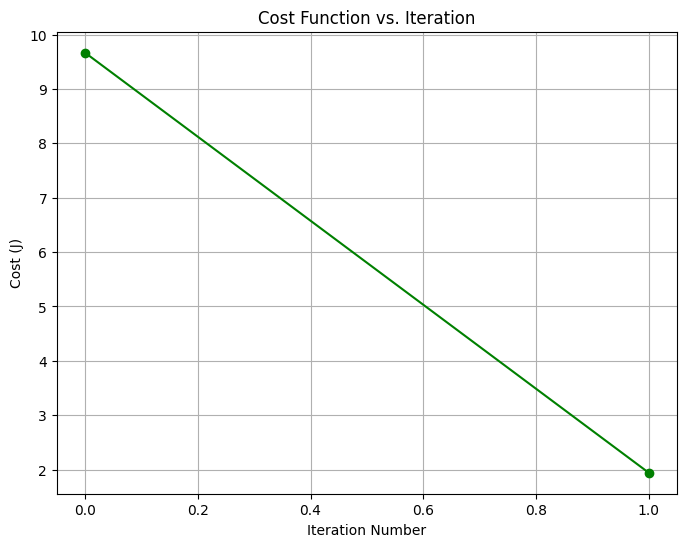

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(range(len(cost_history)), cost_history, color='green', marker='o')
plt.title('Cost Function vs. Iteration')
plt.xlabel('Iteration Number')
plt.ylabel('Cost (J)')
plt.grid(True)
plt.show()

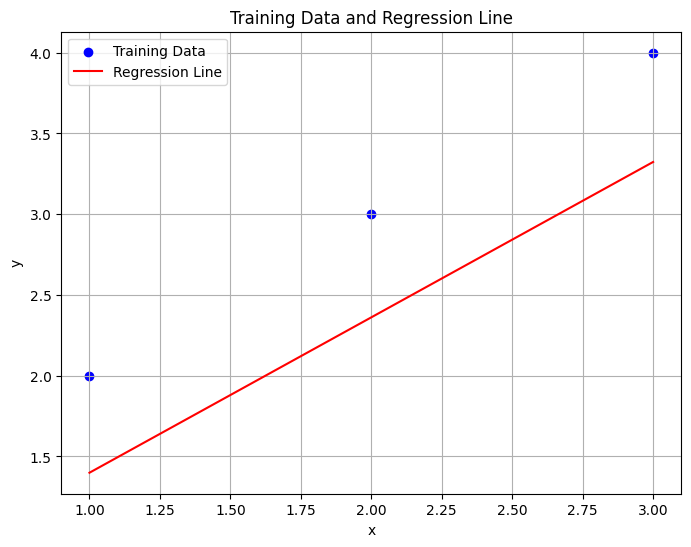

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color='blue', label='Training Data')


y_pred_final = predict(x, w, b)
plt.plot(x, y_pred_final, color='red', label='Regression Line')

plt.title('Training Data and Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()